# Tree Reconstruction


## 1. Import Libraries and Load Data

In [5]:
# Import libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add the main project folder to Python's search path
project_dir = Path("..").resolve()

if str(project_dir) not in sys.path:
    sys.path.append(str(project_dir))

# Import dataset class
from src.dataset import TreeDataset

In [6]:
# Dataset location
data_dir = project_dir / "data/raw/Dataset (With Summer GT)"

# Create dataset
dataset = TreeDataset(data_dir)

# Select one tree for initial reconstruction
tree = dataset.get_tree("R01N01")

print("Tree:", tree.tree_id)
print("Summer RGB:", tree.summer_rgb.shape)
print("Summer Depth:", tree.summer_depth.shape)
print("Summer GT:", tree.summer_gt.shape)
print("Winter RGB:", tree.winter_rgb.shape)
print("Winter Depth:", tree.winter_depth.shape)

Tree: R01N01
Summer RGB: (480, 640, 3)
Summer Depth: (480, 640, 3)
Summer GT: (256, 256)
Winter RGB: (480, 640, 3)
Winter Depth: (480, 640, 3)


## 2. Preprocess Input Data

### 2.1 Check the depth channels

In [7]:
# Check whether the three depth channels contain identical values

summer_channels_equal = (
    np.array_equal(tree.summer_depth[:, :, 0], tree.summer_depth[:, :, 1])
    and
    np.array_equal(tree.summer_depth[:, :, 1], tree.summer_depth[:, :, 2])
)

winter_channels_equal = (
    np.array_equal(tree.winter_depth[:, :, 0], tree.winter_depth[:, :, 1])
    and
    np.array_equal(tree.winter_depth[:, :, 1], tree.winter_depth[:, :, 2])
)

print("Summer depth channels identical:", summer_channels_equal)
print("Winter depth channels identical:", winter_channels_equal)

Summer depth channels identical: True
Winter depth channels identical: True


In [8]:
# The depth PNG stores identical information in all three channels,
# so only one channel is required.

summer_depth = tree.summer_depth[:, :, 0]
winter_depth = tree.winter_depth[:, :, 0]

print("Summer depth shape:", summer_depth.shape)
print("Winter depth shape:", winter_depth.shape)

Summer depth shape: (480, 640)
Winter depth shape: (480, 640)


### 2.2 Identify valid depth pixels

In [9]:
print("Summer depth range:", summer_depth.min(), "-", summer_depth.max())
print("Winter depth range:", winter_depth.min(), "-", winter_depth.max())

print("Summer zero pixels:", np.sum(summer_depth == 0))
print("Winter zero pixels:", np.sum(winter_depth == 0))

print(
    "Summer zero percentage:",
    round(100 * np.mean(summer_depth == 0), 2),
    "%"
)

print(
    "Winter zero percentage:",
    round(100 * np.mean(winter_depth == 0), 2),
    "%"
)

Summer depth range: 0 - 169
Winter depth range: 0 - 145
Summer zero pixels: 36359
Winter zero pixels: 163430
Summer zero percentage: 11.84 %
Winter zero percentage: 53.2 %


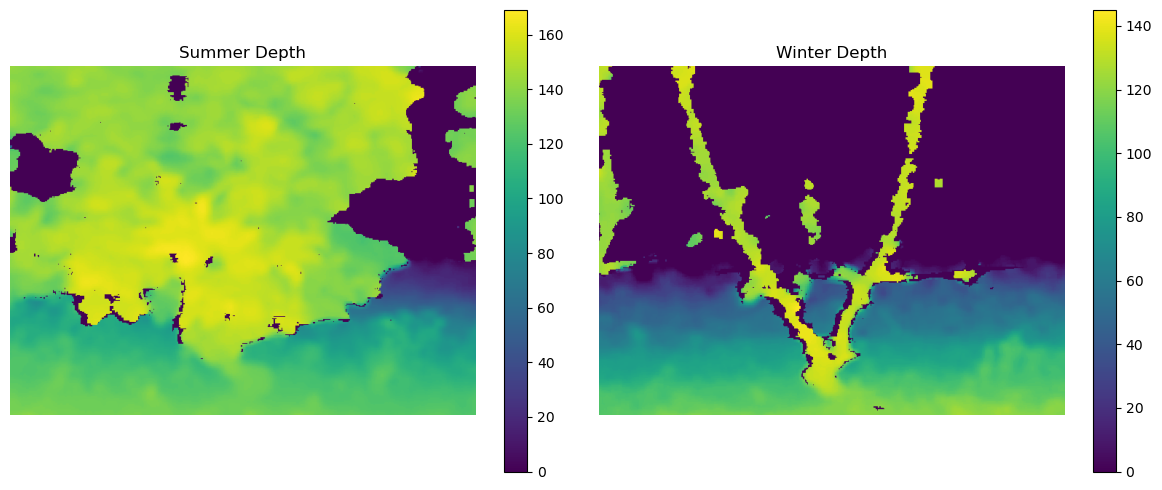

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(summer_depth, cmap="viridis")
axes[0].set_title("Summer Depth")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(winter_depth, cmap="viridis")
axes[1].set_title("Winter Depth")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## 3. Isolate Tree Structure



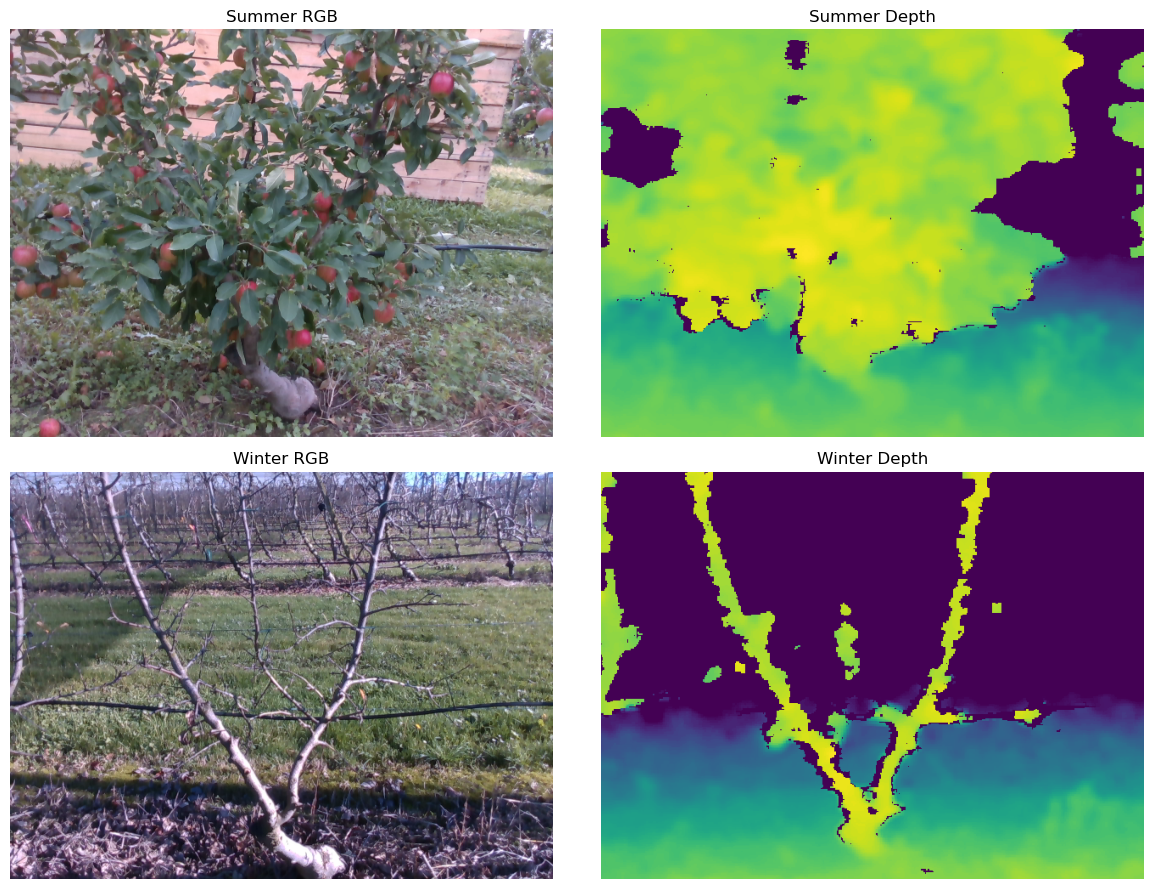

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].imshow(tree.summer_rgb)
axes[0, 0].set_title("Summer RGB")

axes[0, 1].imshow(summer_depth, cmap="viridis")
axes[0, 1].set_title("Summer Depth")

axes[1, 0].imshow(tree.winter_rgb)
axes[1, 0].set_title("Winter RGB")

axes[1, 1].imshow(winter_depth, cmap="viridis")
axes[1, 1].set_title("Winter Depth")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

### RGB-D Observations

The RGB and depth observations have the same image dimensions of 640 × 480 pixels. Visual comparison suggests that for the winter tree the depth is accurate at matching the branch however for the summer the depth just picks up the leaves. .

The winter observation provides greater visibility of the tree's branch structure because there is less in the way of the camera to the branches.

## 4. Convert Tree Data to a Usable Representation



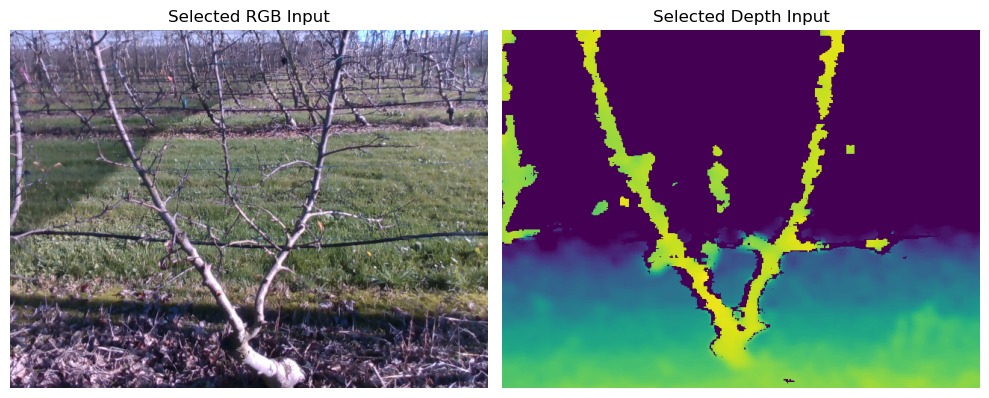

In [12]:
# Use winter observation for initial reconstruction
rgb = tree.winter_rgb
depth = winter_depth

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(rgb)
axes[0].set_title("Selected RGB Input")

axes[1].imshow(depth, cmap="viridis")
axes[1].set_title("Selected Depth Input")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Selected Input

The winter observation was selected for the initial reconstruction because the reduced foliage provides greater visibility of the tree's branch structure.

A reconstruction method will first be developed using a single tree before being applied to additional trees.

## 5. Baseline Skeleton Reconstruction



## 6. Improved Skeleton Reconstruction


## 7. Visualise Final Reconstruction


## 8. Reconstruction Summary
